In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy
from sympy import Symbol, diff, solve, nsolve, solveset, latex, S, simplify, fraction, Union, Interval, intersection, limit
from sympy.calculus.util import continuous_domain
from sympy import sin as Sin
from sympy import cos as Cos
from sympy import pi as Pi
%matplotlib inline

## Занятие 8
## Математический анализ
## Дифференцирование функции, заданной параметрически
Пусть зависимость $y$ от $x$ задана параметрически:
$$
\left\{
\begin{matrix}
x = \varphi(t)\\
y = \psi(t)
\end{matrix}
\right.
$$
тогда производная $y$ по $x$  находится по формуле
$$
y'_x = \frac{y'_t}{x'_t} = \frac{\psi'_t}{\varphi'_t}
$$
Вторая производная:
$$
y''_{xx} = \frac{x'_t y''_{tt}-x''_{tt}y'_t}{(x'_t)^3}  = \frac{\varphi'_t \psi''_{tt}-\varphi''_{tt}\psi'_t}{(\varphi'_t)^3}
$$
### Задание 1
Найти производные 1 и 2 порядка функции
$$
\left\{
\begin{matrix}
x = \sin(t) - t\cos(t)\\
y = \cos(t) + t\sin(t)
\end{matrix}
\right.
$$

In [ ]:
t = Symbol('t')
x = Sin(t) - t * Cos(t)
y = Cos(t) + t * Sin(t)
dx = diff(x, t)
dy = diff(y, t)
dy_x = dy/dx
dy2_xx = (dx*diff(y, t, 2) - diff(x, t, 2)*dy)/dx**3
display(dy_x)

cos(t)/sin(t)

In [ ]:
display(simplify(dy2_xx))

-1/(t*sin(t)**3)

### Задание 2.
Найти нули производных первого и второго порядка, а также точки, в которых эти производные не существуют, для функции
$$
\left\{
\begin{matrix}
x = t^2 - 2t\\
y = t^2 + 2t
\end{matrix}
\right.
$$

In [2]:
t = Symbol('t')
x = t ** 2 - 2 * t
y = t ** 2 +2 * t
dx = diff(x, t)
dy =  diff(y, t)
dy_x = dy/dx
dy2_xx = simplify((dx * diff(y, t, 2) - diff(x, t, 2) * dy) / dx ** 3)
display(dy_x)

(2*t + 2)/(2*t - 2)

In [3]:
display(simplify(dy2_xx))

-1/(t - 1)**3

In [4]:
display("Первая производная:")
dy_x_num, dy_x_den = fraction(dy_x)
dy_x_num_nul = solveset(dy_x_num)
dy_x_den_nul = solveset(dy_x_den)
display(f"Нули числителя {dy_x_num_nul}; Нули знаменателя: {dy_x_den_nul}")

'Первая производная:'

'Нули числителя {-1}; Нули знаменателя: {1}'

In [5]:
display("Вторая производная:")
dy2_xx_num,dy2_xx_den = fraction(dy2_xx)
dy2_xx_num_nul = solveset(dy2_xx_num)
dy2_xx_den_nul = solveset(dy2_xx_den)
display(f"Нули числителя: {dy2_xx_num_nul}; Нули знаменателя: {dy2_xx_den_nul}")

'Вторая производная:'

'Нули числителя: EmptySet; Нули знаменателя: {1}'

### Задание 3.
Найти точки экстремума и точки перегиба функции Задания 2.

In [6]:
crit_points = list(Union(dy_x_num_nul, dy_x_den_nul))
crit_points.sort()
crit_points

[-1, 1]

In [7]:
points = [-2]+[(item + crit_points[i + 1]) / 2 for i, item in enumerate(crit_points[:-1])] + [2]
points

[-2, 0, 2]

In [8]:
max_arr = list()
min_arr = list()
for i, item in enumerate(crit_points):
    if item in dy_x_num_nul:
        df_left = dy_x.subs(t, points[i])
        df_right = dy_x.subs(t, points[i + 1])
        x_left = float(x.subs(t, points[i]))
        x_right = float(x.subs(t, points[i + 1]))
        if df_left < 0 and df_right > 0 and x_left < x_right or df_left > 0 and df_right < 0 and x_left > x_right:
            min_arr.append(item)
        elif df_left < 0 and df_right > 0 and x_left > x_right or df_left > 0 and df_right < 0 and x_left < x_right:
            max_arr.append(item)
display('Mаксимум:', max_arr)

'Mаксимум:'

[]

In [9]:
display('Mинимум:', min_arr)

'Mинимум:'

[-1]

### Задание 4. Точки перегиба
Найти точки перегиба функции, график строить не нужно.
$$
\left\{
\begin{matrix}
x = e^t\\
y = te^{2t}
\end{matrix}
\right.
$$

In [ ]:
from sympy import E
t = Symbol('t')
x = E ** t
y = t * (E ** (2 * t))
dx = diff(x, t)
dy =  diff(y, t)
dy_x = dy / dx
dy2_xx = simplify((dx * diff(y, t, 2) - diff(x, t, 2) * dy) / dx ** 3)
display(dy_x)

(2*t*exp(2*t) + exp(2*t))*exp(-t)

In [ ]:
display(simplify(dy2_xx))

2*t + 3

In [ ]:
dy_x_num, dy_x_den = fraction(dy2_xx)
dy_x_num_nul = solveset(dy_x_num)
dy_x_den_nul = solveset(dy_x_den)
display('Первая производная, нули числителя:', dy_x_num_nul)

'Первая производная, нули числителя:'

{-3/2}

In [ ]:
display('Нули знаменателя:', dy_x_den_nul)

'Нули знаменателя:'

EmptySet

In [ ]:
ans = []
df_left = dy2_xx.subs(t, -2)
df_right = dy2_xx.subs(t, 2)
if df_left < 0 and df_right > 0 or df_left > 0 and df_right < 0:
  ans.append(*dy_x_num_nul)
ans

[-3/2]

## Асимптоты параметрически заданной функции
Пусть зависимость $y$ от $x$ задана параметрически:
$$
\left\{
\begin{matrix}
x = \varphi(t)\\
y = \psi(t)
\end{matrix}
\right.
$$
Сначала нужно определить, нет ли таких значений параметра $t$, при которых одна из функций $\varphi(t)$ или $\psi(t)$ обращается в бесконечность, а другая остается конечной. При $\varphi(t_0) = \infty$, а $\psi(t_0) = c$ кривая имеет горизонтальную асимптоту  $y = c$. При  $\psi(t_0) = \infty$, а $\varphi(t_0) = c$ кривая имеет вертикальную асимптоту $x = c$.

Если $\varphi(t_0) = \psi(t_0) = \infty$ и
$$
\lim_{t\to t_0} \frac{\psi(t)}{\varphi(t)} = k;\qquad \lim_{t\to t_0} [\psi(t) - k\varphi(t)] = b,
$$
то   кривая имеет наклонную асимптоту  $y = kx + b$.

### Индивидуальное задание. Вариант №191
Найти асимптоты параметрически заданной функции и изобразить на графике функцию и ее асимптоты.

In [ ]:
import sympy as sp
x_t = E ** t + E ** (-t)
y_t = 2 * E ** t - 2 * E ** (-t)

In [ ]:
display(limit(x_t, t, 0))
display(limit(y_t, t, 0))

2

0

In [ ]:
display(limit(x_t, t, sp.oo))
display(limit(y_t, t, sp.oo))

oo

oo

In [ ]:
display(limit(x_t, t, -sp.oo))
display(limit(x_t, t, sp.oo))

oo

oo

In [ ]:
k = limit(y_t / x_t, t, sp.oo)
k

2

In [ ]:
k1 = limit(y_t / x_t, t, -sp.oo)
k1

-2

In [ ]:
b = limit(y_t - k * x_t, t, sp.oo)
b

0

In [ ]:
b1 = limit(y_t - k1 * x_t, t, -sp.oo)
b1

0

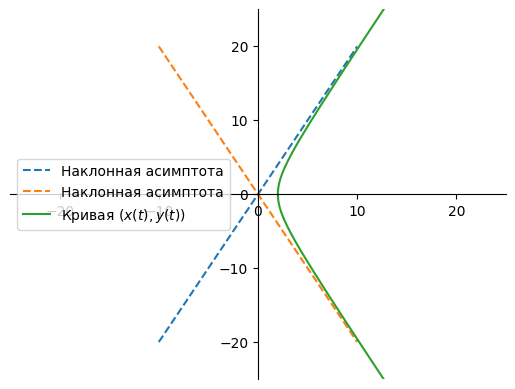

In [ ]:
x = np.linspace(-10, 10, 100)
y = k * x + b
plt.plot(x, y, label='Наклонная асимптота', linestyle='--')
y1 = k1 * x + b1
plt.plot(x, y1, label='Наклонная асимптота', linestyle='--')

t_values = np.linspace(-25, 25, 400)
x_value = [sp.exp(t_val) + sp.exp(-t_val) for t_val in t_values]
y_value = [2 * sp.exp(t_val) - 2 * sp.exp(-t_val) for t_val in t_values]

plt.plot(x_value, y_value, label='Кривая $(x(t), y(t))$')

ax = plt.gca()
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))
plt.ylim(-25, 25)
plt.xlim(-25, 25)

plt.legend()
plt.show()